In [1]:
# Import the Image
import numpy as np
import PIL.Image as Image

# Sampling Image

In [2]:
def sampling(img,sampling_rate):
    """_summary_

    Args:
        img (NumpyArray): Gambar input yang akan di-sampling
        sampling_rate int: Rasio sampling, misalnya 2 berarti mengambil 1 pixel setiap 2 pixel

    Returns:
        sampled_image (NumpyArray) : Image hasil Sampling
    """
    
    # dapatkan ukuran gambar
    width, height = img.shape[1], img.shape[0]
    new_width = width // sampling_rate
    new_height = height // sampling_rate
    
    # buat array kosong untuk menyimpan hasil sampling
    sampled_img = np.zeros((new_height,new_width,3),dtype=np.uint8)
    
    # lakukan sampling dengan mengambil pixel pada posisi tertentu
    for i in range(0,height - (height % sampling_rate),sampling_rate):
        for j in range(0,width - (width % sampling_rate),sampling_rate):
            sampled_img[i//sampling_rate,j//sampling_rate] = img[i,j]
            
    return sampled_img


In [33]:
img_numpy = np.array(Image.open('unnamed.jpg'))
img_numpy.shape # height weight channel

(900, 900, 3)

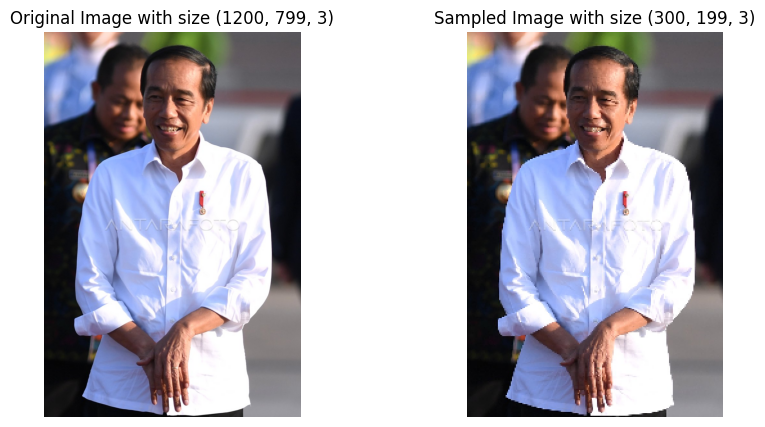

In [4]:
# Test ke contoh gambar
img = Image.open('pak_Jokowi.jpg')
sampling_rate = 4

numpy_img = np.array(img)
sampled_image = sampling(numpy_img, sampling_rate)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
# Original Image
plt.subplot(1,2,1)
plt.title(f'Original Image with size {np.array(img).shape}')
plt.imshow(img)
plt.axis('off')

# Sampled Image
plt.subplot(1,2,2)
plt.title(f'Sampled Image with size {sampled_image.shape}')
plt.imshow(sampled_image)
plt.axis('off')
plt.show()


# Image Quantization

In [ ]:
def quantization_midpoint(img, bit_depth):
    """
    Args:
        img (numpy array): image input (H,W) atau (H,W,3), dtype uint8
        bit_depth (int): jumlah bit per channel (k < 8) dan (k > 0)

    Returns:
        numpy array: hasil quantization midpoint (tetap 0..255)
    """
    
    levels = 2 ** bit_depth
    step = 256 // levels  # sama dengan 2^(8-k)
    
    # hitung bin index
    bin_index = img // step
    
    # hitung midpoint tiap bin
    quantized_img = bin_index * step + step // 2
    
    return quantized_img.astype(np.uint8)

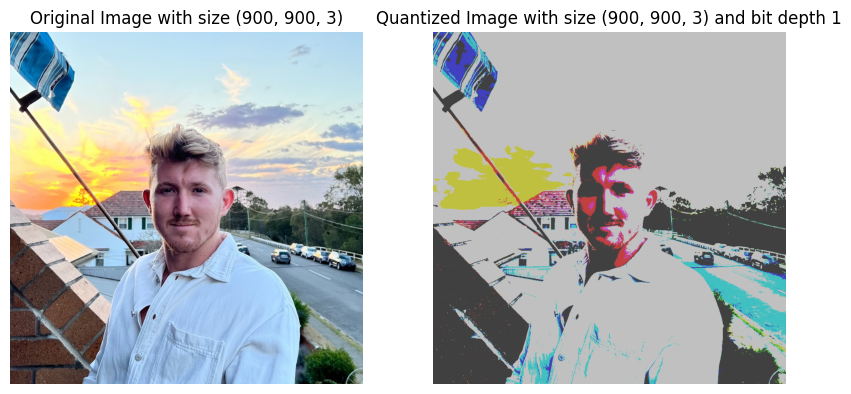

In [29]:
img = Image.open("unnamed.jpg")
bit_depth = 1

quantized_image = quantization_midpoint(np.array(img), bit_depth)
plt.figure(figsize=(10,5))
# Original Image
plt.subplot(1,2,1)
plt.title(f'Original Image with size {np.array(img).shape}')
plt.imshow(img)
plt.axis('off')

# Quantized Image
plt.subplot(1,2,2)
plt.title(f'Quantized Image with size {quantized_image.shape} and bit depth {bit_depth}')
plt.imshow(quantized_image)
plt.axis('off')
plt.show()

# Image Properties

In [ ]:
def calculate_pysical_dimention(memory_size,dpi):
    """
    Args:
        memory_size (int): ukuran memori dalam kilobytes (KB)
        dpi (int): dots per inch (resolusi)

    Returns:
        tuple: dimensi fisik gambar dalam inci (width_inch, height_inch)
    """
    
    # Konversi memory size dari KB ke bytes
    memory_size_bytes = memory_size * 1024
    
    # Hitung total pixel yang dapat disimpan dalam memori
    total_pixels = memory_size_bytes // 3  # 3 bytes per pixel (RGB)
    
    # Hitung dimensi gambar dalam pixel
    width_pixels = int(np.sqrt(total_pixels))
    height_pixels = int(np.sqrt(total_pixels))
    
    # Konversi dimensi dari pixel ke inci
    width_inch = width_pixels / dpi
    height_inch = height_pixels / dpi
    
    return width_inch, height_inch

# Fungsi dengan asumsi gambar persegi dan 3 bytes per pixel (RGB)

Dimensi fisik gambar yang dapat disimpan: 1.97 inch x 1.97 inch


In [ ]:
def calculate_physical_dimension(memory_size_kb: float, dpi: int,
                                  aspect_ratio: tuple = (1, 1),
                                  bytes_per_pixel: int = 3) -> tuple:
    """
    Calculate physical dimensions (inches) from uncompressed memory size and DPI.

    Args:
        memory_size_kb   (float): Uncompressed image size in KB
        dpi              (int)  : Resolution in dots per inch
        aspect_ratio     (tuple): Width-to-height ratio, e.g. (16, 9). Default (1,1) = square
        bytes_per_pixel  (int)  : 1=grayscale, 3=RGB, 4=RGBA. Default 3

    Returns:
        tuple: (width_inch, height_inch, width_px, height_px)
        
    """

    ar_w, ar_h = aspect_ratio


    total_bytes  = memory_size_kb * 1024
    total_pixels = total_bytes / bytes_per_pixel

    k = np.sqrt(total_pixels / (ar_w * ar_h))

    width_px  = int(ar_w * k)
    height_px = int(ar_h * k)

    width_inch  = width_px  / dpi
    height_inch = height_px / dpi

    return width_inch, height_inch, width_px, height_px

# lebih advance